In [1]:

import tensorflow as tf

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Build the Keras model
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)), # Flatten 28x28 images into a 1D array
  tf.keras.layers.Dense(128, activation='relu'), # Hidden layer with 128 neurons and ReLU activation
  tf.keras.layers.Dropout(0.2), # Dropout layer for regularization
  tf.keras.layers.Dense(10, activation='softmax') # Output layer with 10 neurons (for 10 digits) and softmax activation
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
print("Training the model...")
model.fit(x_train, y_train, epochs=5)

# Evaluate the model
print("\nEvaluating the model...")
loss, accuracy = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {accuracy:.4f}")


ModuleNotFoundError: No module named 'tensorflow'

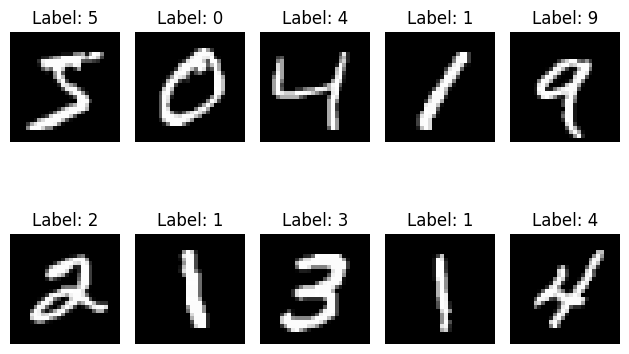

In [3]:
import matplotlib.pyplot as plt
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()

plt.show()

In [6]:
!pip install emnist

In [9]:
import os
from emnist import extract_training_samples, extract_test_samples
import matplotlib.pyplot as plt

# Define the path to the EMNIST cache file
emnist_cache_path = os.path.join(os.path.expanduser('~'), '.emnist', 'emnist.zip')

# Check if the corrupted file exists and remove it
if os.path.exists(emnist_cache_path):
    print(f"Removing corrupted EMNIST cache file: {emnist_cache_path}")
    os.remove(emnist_cache_path)
    print("Corrupted file removed. Attempting download again...")

# 1. Tải dữ liệu (bạn có thể đổi 'balanced' thành 'letters', 'digits', v.v.)
x_train, y_train = extract_training_samples('balanced')
x_test, y_test = extract_test_samples('balanced')

# 2. Kiểm tra kích thước
print(f"Dữ liệu train: {x_train.shape}") # Output: (112800, 28, 28)
print(f"Nhãn train: {y_train.shape}")

# 3. Hiển thị thử để kiểm tra xem có bị ngược không
plt.figure(figsize=(5,5))
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

BadZipFile: File is not a zip file

In [ ]:
# To use EMNIST, you'll typically need to install 'tensorflow_datasets'
# You might need to install it if you haven't already:
# !pip install tensorflow-datasets

import tensorflow as tf
import tensorflow_datasets as tfds

# Load the EMNIST Balanced dataset
# This will download and prepare the dataset the first time it's run.
# The 'as_supervised=True' argument means the dataset will be returned in (image, label) tuples.
print("Loading EMNIST Balanced dataset...")
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

# Define preprocessing functions
def normalize_img(image, label):
  """Normalizes images: `uint8` -> `float32`."""
  return tf.cast(image, tf.float32) / 255., label

def preprocess_emnist_image(image, label):
  # EMNIST images are 28x28. They are often rotated 90 degrees clockwise and flipped vertically
  # compared to typical MNIST orientation. We need to rotate them back.
  image = tf.image.rot90(image, k=3) # Rotate 270 degrees counter-clockwise (or 90 clockwise)
  image = tf.image.flip_left_right(image) # Flip horizontally
  return image, label

# Apply preprocessing
ds_train = ds_train.map(preprocess_emnist_image)
ds_test = ds_test.map(preprocess_emnist_image)

ds_train = ds_train.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.cache()
ds_train = ds_train.shuffle(ds_info.splits['train'].num_examples)
ds_train = ds_train.batch(128)
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)

ds_test = ds_test.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(128)
ds_test = ds_test.cache()
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)

# Build the Keras model (similar to MNIST, but EMNIST Balanced has 47 classes)
# The number of classes can be found in ds_info.features['label'].num_classes
num_classes = ds_info.features['label'].num_classes
print(f"Number of classes in EMNIST Balanced: {num_classes}")

model_emnist = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model_emnist.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

# Train the model
print("\nTraining the EMNIST model...")
model_emnist.fit(ds_train, epochs=5)

# Evaluate the model
print("\nEvaluating the EMNIST model...")
loss_emnist, accuracy_emnist = model_emnist.evaluate(ds_test, verbose=2)
print(f"EMNIST Test accuracy: {accuracy_emnist:.4f}")


Loading EMNIST Balanced dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

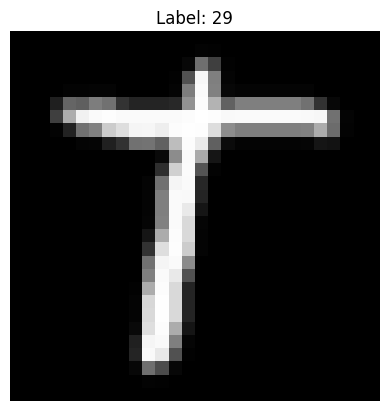

In [7]:
import matplotlib.pyplot as plt

# To get a single element from a tf.data.Dataset, iterate over it
# Take one batch from the training dataset
for image_batch, label_batch in ds_train.take(1):
    # Get the first image and label from the batch
    first_image = image_batch[0]
    first_label = label_batch[0]
    plt.imshow(first_image, cmap='gray')
# Display the first image

plt.title(f"Label: {first_label.numpy()}") # .numpy() converts the TensorFlow tensor to a Python number
plt.axis('off') # Turn off axis numbers and ticks
plt.show()

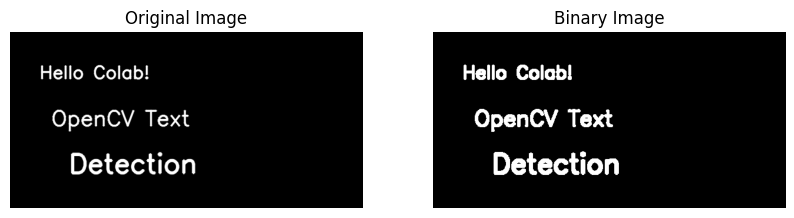

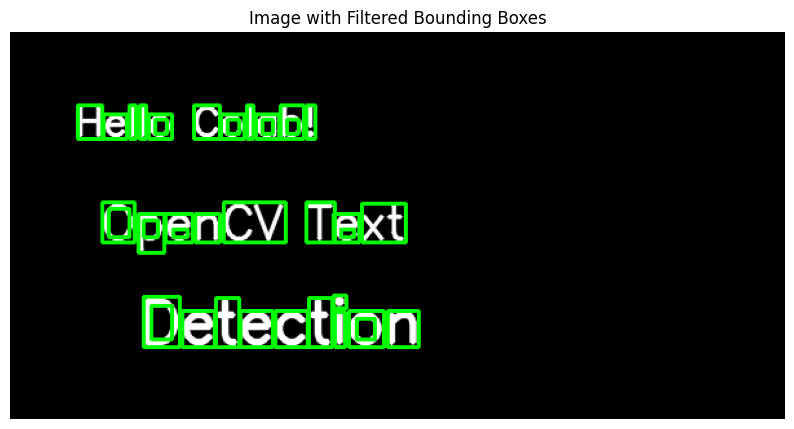

Found 46 contours initially.
Filtered down to 39 potential character/word bounding boxes.


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load Image ---
# For demonstration, let's create a dummy image with some 'text'
# In a real scenario, you would load an image like:
# image = cv2.imread('your_image_path.jpg')
# if image is None: raise FileNotFoundError("Image not found")

# Creating a dummy image with white text on a black background
height, width = 300, 600
image = np.zeros((height, width, 3), dtype=np.uint8) # Black background
font = cv2.FONT_HERSHEY_SIMPLEX

text1 = "Hello Colab!"
text2 = "OpenCV Text"
text3 = "Detection"

# Put text on the image
cv2.putText(image, text1, (50, 80), font, 1, (255, 255, 255), 2, cv2.LINE_AA)
cv2.putText(image, text2, (70, 160), font, 1.2, (255, 255, 255), 2, cv2.LINE_AA)
cv2.putText(image, text3, (100, 240), font, 1.5, (255, 255, 255), 3, cv2.LINE_AA)

# Display original image
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
cv2.imwrite("./image.jpeg", image)
# --- 2. Preprocessing ---
# Convert to grayscale
grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply binary thresholding (Otsu's method often works well for text)
# Changed to THRESH_BINARY to make text white on black background
_, binary_image = cv2.threshold(grayscale_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# (Optional) Apply morphological operations to improve contour detection
# For text, sometimes dilation helps connect broken characters
kernel = np.ones((3,3), np.uint8)
binary_image = cv2.dilate(binary_image, kernel, iterations=1)

plt.subplot(1, 2, 2)
plt.imshow(binary_image, cmap='gray')
plt.title('Binary Image')
plt.axis('off')
plt.show()

# --- 3. Find Contours ---
# Use RETR_LIST to get all contours, not just external ones
contours, hierarchy = cv2.findContours(binary_image, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

# --- 4. Filter Bounding Boxes using Heuristics ---
filtered_boxes = []

# Heuristic parameters (adjust these based on your image and expected character/word sizes)
min_area = 50       # Minimum area for a contour to be considered
max_area = 100000    # Increased max_area to allow for word-sized bounding boxes
min_aspect_ratio = 0.1 # Minimum width/height ratio
max_aspect_ratio = 10  # Maximum width/height ratio

for contour in contours:
    # Get the bounding box coordinates
    x, y, w, h = cv2.boundingRect(contour)

    # Calculate area and aspect ratio
    area = w * h
    if h == 0: # Avoid division by zero
        aspect_ratio = 0
    else:
        aspect_ratio = w / h

    # Apply heuristic filtering
    if min_area < area < max_area and min_aspect_ratio < aspect_ratio < max_aspect_ratio:
        filtered_boxes.append((x, y, w, h))

# --- 5. Visualize Results ---
output_image = image.copy()

for (x, y, w, h) in filtered_boxes:
    # Draw the bounding box (green rectangle with thickness 2)
    cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title('Image with Filtered Bounding Boxes')
plt.axis('off')
plt.show()

print(f"Found {len(contours)} contours initially.")
print(f"Filtered down to {len(filtered_boxes)} potential character/word bounding boxes.")


In [11]:
# Tải file model EAST pre-trained
!wget https://raw.githubusercontent.com/oyyd/frozen_east_text_detection.pb/master/frozen_east_text_detection.pb

# Tải một ảnh mẫu để kiểm tra (hoặc bạn có thể tự upload ảnh của mình)
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/board.jpg -O sample.jpg

--2026-03-31 15:11:07--  https://raw.githubusercontent.com/oyyd/frozen_east_text_detection.pb/master/frozen_east_text_detection.pb
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 96662756 (92M) [application/octet-stream]
Saving to: ‘frozen_east_text_detection.pb’

frozen_east_text_de 100%[===================>]  92.18M  84.3MB/s    in 1.1s    

2026-03-31 15:11:14 (84.3 MB/s) - ‘frozen_east_text_detection.pb’ saved [96662756/96662756]

--2026-03-31 15:11:14--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/board.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
H

In [12]:
import cv2
import numpy as np
from imutils.object_detection import non_max_suppression
from google.colab.patches import cv2_imshow # Dùng thay cho cv2.imshow
import matplotlib.pyplot as plt

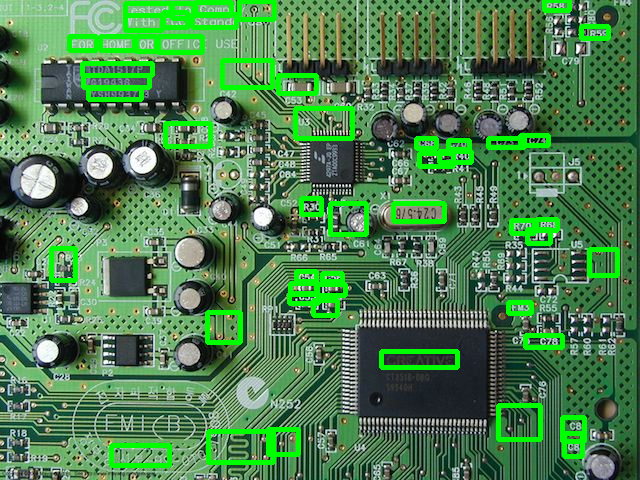

In [19]:
def east_detect_colab(image_path, model_path="frozen_east_text_detection.pb", min_confidence=0.5):
    # Load ảnh và lấy kích thước
    image = cv2.imread(image_path)
    orig = image.copy()
    (H, W) = image.shape[:2]

    # EAST yêu cầu kích thước là bội số của 32
    (newW, newH) = (640, 640)
    rW = W / float(newW)
    rH = H / float(newH)
    image_resized = cv2.resize(image, (newW, newH))

    # Load model EAST
    layerNames = ["feature_fusion/Conv_7/Sigmoid", "feature_fusion/concat_3"]
    net = cv2.dnn.readNet(model_path)

    # Chuyển ảnh thành Blob để đưa vào mạng
    blob = cv2.dnn.blobFromImage(image_resized, 1.0, (newW, newH),
                                 (123.68, 116.78, 103.94), swapRB=True, crop=False)
    net.setInput(blob)
    (scores, geometry) = net.forward(layerNames)

    # Giải mã kết quả (Decoding)
    (numRows, numCols) = scores.shape[2:4]
    rects = []
    confidences = []

    for y in range(0, numRows):
        scoresData = scores[0, 0, y]
        xData0 = geometry[0, 0, y]
        xData1 = geometry[0, 1, y]
        xData2 = geometry[0, 2, y]
        xData3 = geometry[0, 3, y]
        anglesData = geometry[0, 4, y]

        for x in range(0, numCols):
            if scoresData[x] < min_confidence:
                continue

            (offsetX, offsetY) = (x * 4.0, y * 4.0)
            angle = anglesData[x]
            cos = np.cos(angle)
            sin = np.sin(angle)

            h = xData0[x] + xData2[x]
            w = xData1[x] + xData3[x]

            endX = int(offsetX + (cos * xData1[x]) + (sin * xData2[x]))
            endY = int(offsetY - (sin * xData1[x]) + (cos * xData2[x]))
            startX = int(endX - w)
            startY = int(endY - h)

            rects.append((startX, startY, endX, endY))
            confidences.append(scoresData[x])

    # Áp dụng Non-Maximum Suppression để lọc bớt box chồng lấn
    boxes = non_max_suppression(np.array(rects), probs=confidences)

    # Vẽ kết quả
    for (startX, startY, endX, endY) in boxes:
        startX = int(startX * rW)
        startY = int(startY * rH)
        endX = int(endX * rW)
        endY = int(endY * rH)
        cv2.rectangle(orig, (startX, startY), (endX, endY), (0, 255, 0), 3)

    cv2_imshow(orig)

# Chạy thử nghiệm
east_detect_colab("sample.jpg")

In [2]:
!pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)



image 1/1 /content/image.jpeg: 320x640 (no detections), 188.1ms
Speed: 3.2ms preprocess, 188.1ms inference, 0.7ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/detect/predict3


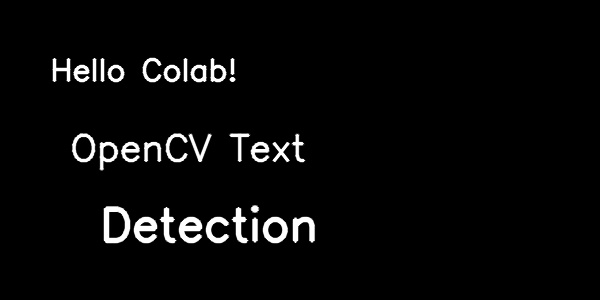

In [5]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# 1. Tải model (Sử dụng weights chuyên cho Text Detection nếu có, hoặc Nano để test)
# Bạn có thể tìm các file 'best.pt' chuyên cho text trên Hugging Face hoặc Roboflow
model = YOLO('yolov8n.pt') # Bản nano cực nhanh

# 2. Chạy detection trên một ảnh
results = model.predict(source='image.jpeg', conf=0.75, save=True)

# 3. Hiển thị kết quả
for result in results:
    res_plotted = result.plot()
    cv2_imshow(res_plotted)

In [8]:
!pip install transformers datasets sentencepiece

In [9]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import requests

# 1. Load model và processor từ Hugging Face
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

# 2. Chuẩn bị ảnh (Ví dụ từ bộ dữ liệu IAM)
url = "https://fki.tic.heia-fr.ch/static/img/a01-122u-02-02.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# 3. Xử lý ảnh và tạo văn bản
pixel_values = processor(image, return_tensors="pt").pixel_values
generated_ids = model.generate(pixel_values)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print(f"Kết quả nhận diện: {generated_text}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

ConnectTimeout: HTTPSConnectionPool(host='fki.tic.heia-fr.ch', port=443): Max retries exceeded with url: /static/img/a01-122u-02-02.jpg (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x7c3ce5ed8290>, 'Connection to fki.tic.heia-fr.ch timed out. (connect timeout=None)'))